# Green cover and precipitation analysis

In [18]:
import pathlib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

#settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

data_folder = pathlib.Path(".")
station_pattern = "dados_A*_M_*.csv"
if not any(data_folder.glob(station_pattern)) and pathlib.Path("/mnt/data").exists():
    data_folder = pathlib.Path("/mnt/data")
green_files = {"Landsat": data_folder / "monthly_green_clean.csv", "Sentinel": data_folder / "monthly_green_clean_sent.csv",}
min_stations_for_average = 1
remove_precipitation_outliers = False
precipitation_iqr_multiplier = 4.0
min_valid_pct = 10.0
min_pred_pct = 10.0
require_use_flag = True
remove_bad_image_flags = True
plot_start_date = pd.Timestamp("2008-01-01") #can change to 2003, but only one station goes back that far
complete_year_months = 12
month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
sensor_styles = {"Landsat": {"color": "darkgreen", "marker": "o", "linestyle": "-"},
    "Sentinel": {"color": "limegreen", "marker": "^", "linestyle": "--"},}
print(f"Data folder: {data_folder.resolve()}")
for sensor, file_path in green_files.items():
    print(f"{sensor}: {file_path.name}")

Data folder: /Users/aishling/Desktop/Project/Vidoe_processing
Landsat: monthly_green_clean.csv
Sentinel: monthly_green_clean_sent.csv


In [19]:
#functions
def parse_station_metadata(file_path, metadata_lines=9):
    metadata = {}
    with open(file_path, "r", encoding="utf-8-sig", errors="replace") as handle:
        for _ in range(metadata_lines):
            line = handle.readline().strip()
            if ":" in line:
                key, value = line.split(":", 1)
                metadata[key.strip()] = value.strip()
    return metadata

def upper_extreme_iqr_flag(series, multiplier=3.0):
    values = pd.to_numeric(series, errors="coerce")
    valid = values.dropna()
    if valid.empty:
        return pd.Series(False, index=series.index, dtype=bool), np.nan
    q1 = valid.quantile(0.25)
    q3 = valid.quantile(0.75)
    upper_fence = q3 + multiplier * (q3 - q1)
    return (values > upper_fence).fillna(False), upper_fence
    
def load_monthly_station(file_path, remove_outliers=False, iqr_multiplier=3.0):
    file_path = pathlib.Path(file_path)
    metadata = parse_station_metadata(file_path)
    station_code = metadata.get("Codigo Estacao",
        file_path.stem.split("_")[1] if "_" in file_path.stem else file_path.stem,)
    station_name = metadata.get("Nome", station_code)
    raw = pd.read_csv(file_path,sep=";",
        skiprows=10,usecols=[0, 1],na_values=["null", "NULL", "", "NA", "NaN"],)
    raw.columns = ["date", "precip_mm"]
    raw["date"] = pd.to_datetime(raw["date"], errors="coerce")
    raw["date"] = raw["date"].dt.to_period("M").dt.to_timestamp()
    raw["precip_mm"] = pd.to_numeric(raw["precip_mm"], errors="coerce")
    raw["invalid_date"] = raw["date"].isna()
    raw["negative_precip"] = raw["precip_mm"] < 0
    raw.loc[raw["negative_precip"], "precip_mm"] = np.nan
    duplicate_rows = int(raw.duplicated(subset="date", keep=False).sum())
    monthly = (raw.dropna(subset=["date"])
        .groupby("date", as_index=False).agg(precip_mm=("precip_mm", "mean"))
        .sort_values("date"))
    monthly["potential_outlier"], upper_fence = upper_extreme_iqr_flag(
        monthly["precip_mm"], multiplier=iqr_multiplier)
    outlier_count = int(monthly["potential_outlier"].sum())
    if remove_outliers:
        monthly.loc[monthly["potential_outlier"], "precip_mm"] = np.nan
    report = {
        "station_code": station_code,
        "station_name": station_name,
        "latitude": pd.to_numeric(metadata.get("Latitude"), errors="coerce"),
        "longitude": pd.to_numeric(metadata.get("Longitude"), errors="coerce"),
        "altitude_m": pd.to_numeric(metadata.get("Altitude"), errors="coerce"),
        "source_rows": len(raw),
        "invalid_dates": int(raw["invalid_date"].sum()),
        "negative_values_removed": int(raw["negative_precip"].sum()),
        "duplicate_rows": duplicate_rows,
        "valid_months": int(monthly["precip_mm"].notna().sum()),
        "missing_months_in_file": int(monthly["precip_mm"].isna().sum()),
        "potential_outliers": outlier_count,
        "upper_extreme_fence_mm": upper_fence,}
    precip_column = f"precip_{station_code}_mm"
    monthly = monthly[["date", "precip_mm"]].rename(columns={"precip_mm": precip_column})
    return monthly.set_index("date"), report

def parse_bool_series(series):
    if pd.api.types.is_bool_dtype(series):
        return series.astype("boolean")
    return (series.astype(str).str.strip().str.lower()
        .map({"true": True, "1": True, "yes": True, "y": True,
            "false": False, "0": False, "no": False, "n": False,
            "nan": pd.NA, "none": pd.NA, "": pd.NA,}).astype("boolean"))

def load_green_cover(file_path, min_valid=10.0, min_pred=10.0,
                     require_use=True, remove_bad_flags=True):
    file_path = pathlib.Path(file_path)
    raw = pd.read_csv(file_path)
    raw.columns = [str(column).strip().lower() for column in raw.columns]
    required = {"date", "green_pct"}
    missing = sorted(required.difference(raw.columns))
    if missing:
        raise ValueError(
            f"{file_path.name} is missing required columns {missing}. "
            f"Available columns: {raw.columns.tolist()}")

    numeric_columns = [
        "valid_pct", "pred_pct", "mean_ndvi", "median_ndvi", "green_pct",
        "year", "month", "valid_pixels", "pred_pixels", "green_pixels",]
    for column in numeric_columns:
        if column in raw.columns:
            raw[column] = pd.to_numeric(raw[column], errors="coerce")

    raw["date"] = pd.to_datetime(raw["date"], errors="coerce")
    if {"year", "month"}.issubset(raw.columns):
        fallback_date = pd.to_datetime(dict(year=raw["year"], month=raw["month"], day=1), errors="coerce")
        raw["date"] = raw["date"].fillna(fallback_date)
    raw["date"] = raw["date"].dt.to_period("M").dt.to_timestamp()
    raw["invalid_date"] = raw["date"].isna()
    if {"year", "month"}.issubset(raw.columns):
        raw["date_component_mismatch"] = (
            raw["date"].notna()
            & ((raw["date"].dt.year != raw["year"]) | (raw["date"].dt.month != raw["month"])))
    else:
        raw["date_component_mismatch"] = False
    quality_mask = raw["date"].notna() & raw["green_pct"].between(0, 100, inclusive="both")
    if "mean_ndvi" in raw.columns:
        quality_mask &= raw["mean_ndvi"].between(-1, 1, inclusive="both")
    if "median_ndvi" in raw.columns:
        quality_mask &= raw["median_ndvi"].between(-1, 1, inclusive="both")
    if "valid_pct" in raw.columns:
        quality_mask &= raw["valid_pct"].between(min_valid, 100, inclusive="both")
    if "pred_pct" in raw.columns:
        quality_mask &= raw["pred_pct"].between(min_pred, 100, inclusive="both")
    if require_use and "use" in raw.columns:
        quality_mask &= parse_bool_series(raw["use"]).fillna(False)

    if remove_bad_flags:
        for column in ["bad_valid", "bad_pred", "bad_ndvi", "bad_green", "zero_green", "bad_image"]:
            if column in raw.columns:
                quality_mask &= ~parse_bool_series(raw[column]).fillna(False)

    accepted = raw.loc[quality_mask].copy()
    duplicate_rows = int(accepted.duplicated(subset="date", keep=False).sum())
    accepted["quality_score"] = 0.0
    for column in ["valid_pct", "pred_pct"]:
        if column in accepted.columns:
            accepted["quality_score"] += accepted[column].fillna(0)

    cleaned = (
        accepted.sort_values(["date", "quality_score"], ascending=[True, False])
        .drop_duplicates(subset="date", keep="first")
        .sort_values("date")
        [["date", "green_pct"]]
        .rename(columns={"green_pct": "green_cover_pct"}).copy())

    report = {
        "source_file": file_path.name,
        "source_rows": len(raw),
        "invalid_dates": int(raw["invalid_date"].sum()),
        "date_component_mismatches": int(raw["date_component_mismatch"].sum()),
        "rows_rejected_by_cleaning": int((~quality_mask).sum()),
        "duplicate_rows_after_cleaning": duplicate_rows,
        "clean_months": len(cleaned),
        "first_clean_month": cleaned["date"].min(),
        "last_clean_month": cleaned["date"].max(),}
    return cleaned, report

def build_sensor_calendar(sensor_green, precip_dataframe, sensor_name):
    green_start = sensor_green["date"].min()
    green_end = sensor_green["date"].max()
    precip_start = precip_dataframe["date"].min()
    precip_end = precip_dataframe["date"].max()
    start_date = max(green_start, precip_start)
    end_date = min(green_end, precip_end)
    if pd.isna(start_date) or pd.isna(end_date) or start_date > end_date:
        raise ValueError(f"No overlapping green-cover and precipitation period for {sensor_name}.")

    calendar = (
        pd.DataFrame({"date": pd.date_range(start=start_date, end=end_date, freq="MS")})
        .merge(sensor_green.drop(columns=["sensor"], errors="ignore"), on="date", how="left")
        .merge(precip_dataframe, on="date", how="left"))
    calendar["sensor"] = sensor_name
    calendar["has_green"] = calendar["green_cover_pct"].notna()
    calendar["has_precip"] = calendar["mean_precip_mm"].notna()
    calendar["has_both"] = calendar["has_green"] & calendar["has_precip"]
    return calendar

In [20]:
#loads and clean precipitation data
station_files = sorted(data_folder.glob(station_pattern))
if not station_files:
    raise FileNotFoundError(f"No station files matching {station_pattern!r} were found in {data_folder.resolve()}.")

station_frames = []
station_reports = []
for station_file in station_files:
    station_df, report = load_monthly_station(
        station_file,
        remove_outliers=remove_precipitation_outliers,
        iqr_multiplier=precipitation_iqr_multiplier,)
    station_frames.append(station_df)
    station_reports.append(report)

station_qc_df = pd.DataFrame(station_reports).sort_values("station_code").reset_index(drop=True)
precip_all = pd.concat(station_frames, axis=1).sort_index()
precip_columns = [column for column in precip_all.columns
    if column.startswith("precip_") and column.endswith("_mm")]
if not precip_columns:
    raise RuntimeError("No precipitation value columns were created.")
precip_all = precip_all.asfreq("MS")
precip_all["stations_available"] = precip_all[precip_columns].notna().sum(axis=1)
precip_all["mean_precip_mm"] = precip_all[precip_columns].mean(axis=1)
precip_all.loc[
    precip_all["stations_available"] < min_stations_for_average, "mean_precip_mm"] = np.nan
precip_df = precip_all.reset_index()
station_count = len(precip_columns)
precip_legend_label = f"Available-station mean precipitation (up to {station_count} stations)"
precip_axis_label = f"Mean monthly precipitation across available stations (up to {station_count}) (mm)"
print(f"Precipitation period: {precip_df['date'].min():%Y-%m} to {precip_df['date'].max():%Y-%m}")
print(f"Stations found: {station_count}")
print(f"Months with usable precipitation: {precip_df['mean_precip_mm'].notna().sum()}")
print(f"Potential station outliers flagged: {int(station_qc_df['potential_outliers'].sum())}")
print(station_qc_df.to_string(index=False))

Precipitation period: 2003-01 to 2026-05
Stations found: 4
Months with usable precipitation: 268
Potential station outliers flagged: 9
station_code    station_name   latitude  longitude  altitude_m  source_rows  invalid_dates  negative_values_removed  duplicate_rows  valid_months  missing_months_in_file  potential_outliers  upper_extreme_fence_mm
        A408       ITABERABA -12.524167 -40.299722      250.11          281              0                        0               0           211                      70                   6                  196.40
        A424           IRECE -11.328889 -41.864444      768.42          219              0                        0               0           192                      27                   0                  306.85
        A426        GUANAMBI -14.208056 -42.749722      552.23          218              0                        0               0           161                      57                   1                  299.00
        A

In [21]:
#load and clean green cover data
#should be cleaned already from CNN, however included as a fail safe
monthly_frames = []
report_rows = []
for sensor, green_file in green_files.items():
    if not green_file.exists():
        raise FileNotFoundError(f"{sensor} green-cover file not found: {green_file.resolve()}")

    monthly_df, report = load_green_cover(green_file,min_valid=min_valid_pct,
        min_pred=min_pred_pct,require_use=require_use_flag,remove_bad_flags=remove_bad_image_flags,)
    monthly_df["sensor"] = sensor
    monthly_frames.append(monthly_df)
    report["sensor"] = sensor
    report_rows.append(report)

green_monthly = (pd.concat(monthly_frames, ignore_index=True)
    .sort_values(["sensor", "date"]).reset_index(drop=True))
green_qc_df = pd.DataFrame(report_rows).sort_values("sensor").reset_index(drop=True)
print(f"Minimum valid-pixel percentage: {min_valid_pct:.1f}%")
print(f"Minimum prediction coverage: {min_pred_pct:.1f}%")
print(f"Require use flag: {require_use_flag}")
print(f"Remove bad-image flags: {remove_bad_image_flags}")
print(green_qc_df.to_string(index=False))

Minimum valid-pixel percentage: 10.0%
Minimum prediction coverage: 10.0%
Require use flag: True
Remove bad-image flags: True
                 source_file  source_rows  invalid_dates  date_component_mismatches  rows_rejected_by_cleaning  duplicate_rows_after_cleaning  clean_months first_clean_month last_clean_month   sensor
     monthly_green_clean.csv          292              0                          0                          0                              0           292        1990-01-01       2026-05-01  Landsat
monthly_green_clean_sent.csv           90              0                          0                          0                              0            90        2018-12-01       2026-05-01 Sentinel


In [22]:
#builds sensor specific monthly calendars
calendar_frames = []
for sensor in green_files:
    sensor_green = green_monthly.loc[green_monthly["sensor"].eq(sensor)].copy()
    calendar_frames.append(build_sensor_calendar(sensor_green, precip_df, sensor))

calendar_df = (pd.concat(calendar_frames, ignore_index=True)
    .sort_values(["sensor", "date"]).reset_index(drop=True))

if calendar_df.duplicated(subset=["sensor", "date"], keep=False).any():
    raise RuntimeError("Duplicate sensor-month rows remain.")
availability_summary = (calendar_df.groupby("sensor", as_index=False)
    .agg(calendar_months=("date", "size"),months_with_green=("has_green", "sum"),
        months_with_precipitation=("has_precip", "sum"),months_with_both=("has_both", "sum"),
        first_calendar_month=("date", "min"),last_calendar_month=("date", "max"),))

print(availability_summary.to_string(index=False))
print("\nMatched analysis periods:")
for sensor, group in calendar_df.loc[calendar_df["has_both"]].groupby("sensor"):
    if len(group) < 4:
        warnings.warn(f"{sensor} has only {len(group)} matched months.")
    else:
        print(f"{sensor}: {group['date'].min():%Y-%m} to {group['date'].max():%Y-%m}; {len(group)} months")

  sensor  calendar_months  months_with_green  months_with_precipitation  months_with_both first_calendar_month last_calendar_month
 Landsat              281                226                        268               214           2003-01-01          2026-05-01
Sentinel               90                 90                         86                86           2018-12-01          2026-05-01

Matched analysis periods:
Landsat: 2003-03 to 2026-05; 214 months
Sentinel: 2018-12 to 2026-05; 86 months


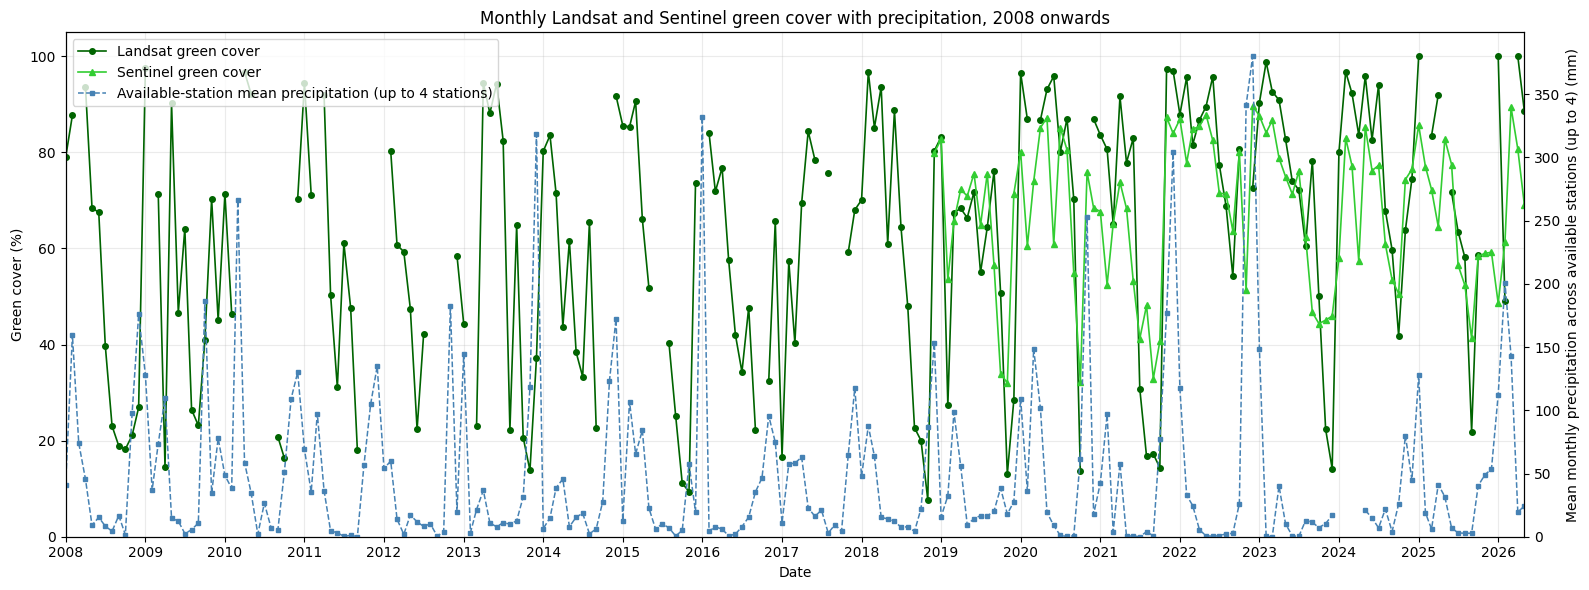

In [23]:
#green cover and precipitation with time
green_plot = calendar_df.loc[calendar_df["date"] >= plot_start_date].copy()
precip_plot = precip_df.loc[precip_df["date"] >= plot_start_date].copy()

fig, ax1 = plt.subplots(figsize=(16, 6))
for sensor, group in green_plot.groupby("sensor"):
    style = sensor_styles.get(sensor, {"color": "seagreen", "marker": "s", "linestyle": "-"})
    ax1.plot(group["date"], group["green_cover_pct"],
        color=style["color"], marker=style["marker"], linestyle="-",
        markersize=4, linewidth=1.2, label=f"{sensor} green cover",)

ax1.set_xlabel("Date")
ax1.set_ylabel("Green cover (%)")
ax1.set_ylim(0, 105)
ax1.set_xlim(left=plot_start_date,right=max(calendar_df["date"].max(), precip_df["date"].max()),)

ax2 = ax1.twinx()
ax2.plot(precip_plot["date"], precip_plot["mean_precip_mm"],
    color="steelblue", marker="s", linestyle="--",markersize=3, linewidth=1.1, label=precip_legend_label,)
ax2.set_ylabel(precip_axis_label)
ax2.set_ylim(bottom=0)

ax1.xaxis.set_major_locator(mdates.YearLocator(1))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
green_handles, green_labels = ax1.get_legend_handles_labels()
precip_handles, precip_labels = ax2.get_legend_handles_labels()
ax1.legend(green_handles + precip_handles, green_labels + precip_labels, loc="upper left")
ax1.grid(alpha=0.25)
ax1.set_title(
    f"Monthly Landsat and Sentinel green cover with precipitation, "
    f"{plot_start_date.year} onwards")
fig.tight_layout()
plt.show()

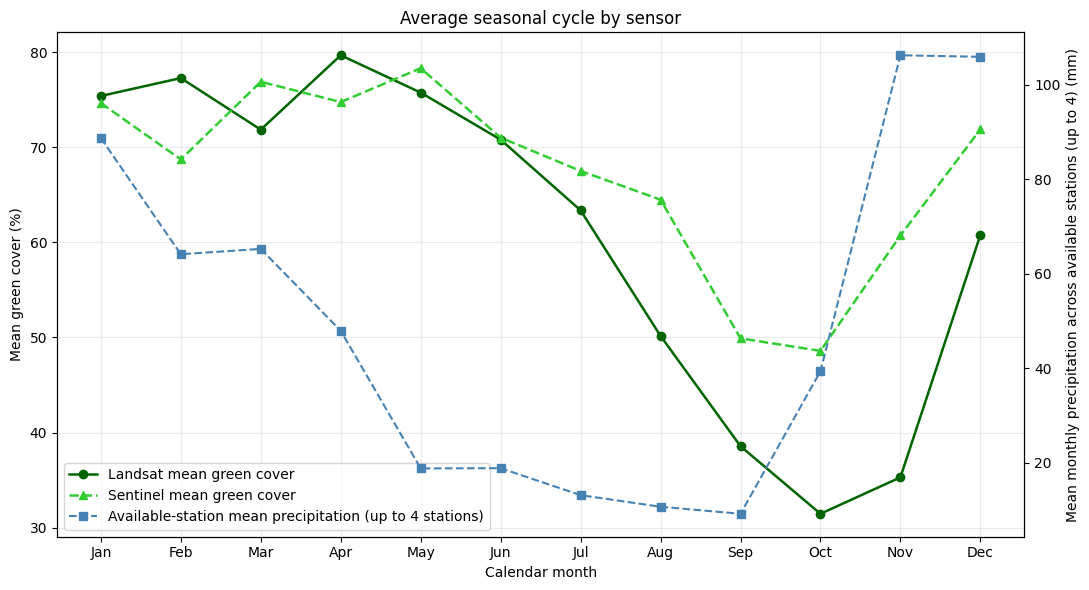

In [24]:
#monthly cycles using averages
green_seasonal_df = (calendar_df.assign(month=calendar_df["date"].dt.month)
    .groupby(["sensor", "month"], as_index=False).agg(mean_green_cover_pct=("green_cover_pct", "mean")))

precip_seasonal_df = (precip_df.assign(month=precip_df["date"].dt.month)
    .groupby("month", as_index=False).agg(mean_precip_mm=("mean_precip_mm", "mean")))

fig, ax1 = plt.subplots(figsize=(11, 6))
for sensor, group in green_seasonal_df.groupby("sensor"):
    group = group.sort_values("month")
    style = sensor_styles.get(sensor, {"color": "seagreen", "marker": "D", "linestyle": ":"})
    ax1.plot(group["month"], group["mean_green_cover_pct"],
        color=style["color"], marker=style["marker"], linestyle=style["linestyle"],
        linewidth=1.8, markersize=6, label=f"{sensor} mean green cover",)

ax1.set_xlabel("Calendar month")
ax1.set_ylabel("Mean green cover (%)")
ax1.set_xticks(range(1, 13), month_labels)
ax2 = ax1.twinx()
ax2.plot(precip_seasonal_df["month"], precip_seasonal_df["mean_precip_mm"],
    color="steelblue", marker="s", linestyle="--",linewidth=1.5, label=precip_legend_label,)
ax2.set_ylabel(precip_axis_label)
green_handles, green_labels = ax1.get_legend_handles_labels()
precip_handles, precip_labels = ax2.get_legend_handles_labels()
ax1.legend(green_handles + precip_handles, green_labels + precip_labels, loc="lower left")
ax1.grid(alpha=0.25)
ax1.set_title("Average seasonal cycle by sensor")
fig.tight_layout()
plt.show()

In [25]:
#full precipitation data analysis
precip_analysis = (precip_df[["date", "mean_precip_mm", "stations_available"]]
    .dropna(subset=["date"]).sort_values("date").reset_index(drop=True))
precip_analysis["year"] = precip_analysis["date"].dt.year
precip_analysis["month"] = precip_analysis["date"].dt.month
print(f"Calendar period: {precip_analysis['date'].min():%Y-%m} to {precip_analysis['date'].max():%Y-%m}")
print(f"Calendar months: {len(precip_analysis)}")
print(f"Months with usable precipitation: {precip_analysis['mean_precip_mm'].notna().sum()}")
print(precip_analysis["stations_available"].value_counts().sort_index())

Calendar period: 2003-01 to 2026-05
Calendar months: 281
Months with usable precipitation: 268
stations_available
0    13
1    61
2    40
3    77
4    90
Name: count, dtype: int64


In [26]:
annual_precip = (precip_analysis.groupby("year")
    .agg(annual_precip_mm=("mean_precip_mm", lambda values: values.sum(min_count=1)),
        avg_monthly_precip_mm=("mean_precip_mm", "mean"),
        median_monthly_precip_mm=("mean_precip_mm", "median"),
        max_monthly_precip_mm=("mean_precip_mm", "max"),
        min_monthly_precip_mm=("mean_precip_mm", "min"),
        precip_months_available=("mean_precip_mm", "count"),
        avg_stations_available=("stations_available", "mean"),
        min_stations_available=("stations_available", "min"),
        max_stations_available=("stations_available", "max"),).reset_index())
annual_precip["complete_precip_year"] = annual_precip["precip_months_available"].eq(complete_year_months)
print(annual_precip.to_string(index=False))

 year  annual_precip_mm  avg_monthly_precip_mm  median_monthly_precip_mm  max_monthly_precip_mm  min_monthly_precip_mm  precip_months_available  avg_stations_available  min_stations_available  max_stations_available  complete_precip_year
 2003        337.200000              30.654545                 15.400000              81.600000               2.400000                       11                0.916667                       0                       1                 False
 2004        747.400000              62.283333                 40.600000             295.600000               0.200000                       12                1.000000                       1                       1                  True
 2005        452.000000              64.571429                 63.400000             124.800000               9.200000                        7                0.583333                       0                       1                 False
 2006        469.600000              52.177778  

In [27]:
complete_years = annual_precip.loc[annual_precip["complete_precip_year"] & annual_precip["annual_precip_mm"].notna()].copy()
complete_years["wettest_rank"] = (complete_years["annual_precip_mm"].rank(method="min", ascending=False).astype("Int64"))
complete_years["driest_rank"] = (complete_years["annual_precip_mm"].rank(method="min", ascending=True).astype("Int64"))
annual_precip = annual_precip.merge(complete_years[["year", "wettest_rank", "driest_rank"]],on="year", how="left",)
annual_precip["wettest_rank"] = annual_precip["wettest_rank"].astype("Int64")
annual_precip["driest_rank"] = annual_precip["driest_rank"].astype("Int64")
ranked_years = annual_precip.loc[annual_precip["complete_precip_year"]].copy()
top_wettest = ranked_years.nsmallest(5, "wettest_rank")[["year", "annual_precip_mm", "avg_monthly_precip_mm", "wettest_rank"]]
top_driest = ranked_years.nsmallest(5, "driest_rank")[["year", "annual_precip_mm", "avg_monthly_precip_mm", "driest_rank"]]
if ranked_years.empty:
    print("No complete 12-month precipitation years are available for ranking.")
else:
    wettest_year = ranked_years.loc[ranked_years["annual_precip_mm"].idxmax()]
    driest_year = ranked_years.loc[ranked_years["annual_precip_mm"].idxmin()]
    print("Wettest complete year:")
    print(wettest_year.to_string())
    print("\nDriest complete year:")
    print(driest_year.to_string())
    print("\nTop five wettest complete years:")
    print(top_wettest.to_string(index=False))
    print("\nTop five driest complete years:")
    print(top_driest.to_string(index=False))

Wettest complete year:
year                              2022
annual_precip_mm            934.566667
avg_monthly_precip_mm        77.880556
median_monthly_precip_mm          15.0
max_monthly_precip_mm            380.0
min_monthly_precip_mm         0.333333
precip_months_available             12
avg_stations_available        1.833333
min_stations_available               1
max_stations_available               3
complete_precip_year              True
wettest_rank                         1
driest_rank                         19

Driest complete year:
year                             2023
annual_precip_mm                259.0
avg_monthly_precip_mm       21.583333
median_monthly_precip_mm         10.3
max_monthly_precip_mm           148.8
min_monthly_precip_mm             0.0
precip_months_available            12
avg_stations_available       1.666667
min_stations_available              1
max_stations_available              3
complete_precip_year             True
wettest_rank                 

In [28]:
valid_precip = precip_analysis.dropna(subset=["mean_precip_mm"]).copy()
max_indices = valid_precip.groupby("year")["mean_precip_mm"].idxmax()
min_indices = valid_precip.groupby("year")["mean_precip_mm"].idxmin()

yearly_max = (valid_precip.loc[max_indices, ["year", "date", "mean_precip_mm", "stations_available"]]
    .rename(columns={"date": "wettest_month","mean_precip_mm": "max_monthly_precip_mm",
        "stations_available": "stations_in_wettest_month",}))
yearly_min = (
    valid_precip.loc[min_indices, ["year", "date", "mean_precip_mm", "stations_available"]]
    .rename(columns={"date": "driest_month","mean_precip_mm": "min_monthly_precip_mm",
        "stations_available": "stations_in_driest_month",}))

yearly_extremes = (
    annual_precip[["year", "avg_monthly_precip_mm", "precip_months_available", "complete_precip_year"]]
    .merge(yearly_max, on="year", how="left").merge(yearly_min, on="year", how="left"))
yearly_extremes["wettest_month"] = yearly_extremes["wettest_month"].dt.strftime("%Y-%m")
yearly_extremes["driest_month"] = yearly_extremes["driest_month"].dt.strftime("%Y-%m")

complete_extremes = yearly_extremes.loc[yearly_extremes["complete_precip_year"]].copy()
complete_extremes["max_precip_rank"] = (
    complete_extremes["max_monthly_precip_mm"].rank(method="min", ascending=False).astype("Int64"))
complete_extremes["min_precip_rank"] = (
    complete_extremes["min_monthly_precip_mm"].rank(method="min", ascending=True).astype("Int64"))
yearly_extremes = yearly_extremes.merge(
    complete_extremes[["year", "max_precip_rank", "min_precip_rank"]],on="year", how="left",)
yearly_extremes["max_precip_rank"] = yearly_extremes["max_precip_rank"].astype("Int64")
yearly_extremes["min_precip_rank"] = yearly_extremes["min_precip_rank"].astype("Int64")
print(yearly_extremes[
    ["year", "wettest_month", "max_monthly_precip_mm", "max_precip_rank",
        "driest_month", "min_monthly_precip_mm", "min_precip_rank","avg_monthly_precip_mm", "precip_months_available",]].to_string(index=False))

 year wettest_month  max_monthly_precip_mm  max_precip_rank driest_month  min_monthly_precip_mm  min_precip_rank  avg_monthly_precip_mm  precip_months_available
 2003       2003-11              81.600000             <NA>      2003-10               2.400000             <NA>              30.654545                       11
 2004       2004-01             295.600000                5      2004-08               0.200000                4              62.283333                       12
 2005       2005-11             124.800000             <NA>      2005-09               9.200000             <NA>              64.571429                        7
 2006       2006-03             115.800000             <NA>      2006-01              14.400000             <NA>              52.177778                        9
 2007       2007-02             254.400000                7      2007-10               5.100000               18              60.416667                       12
 2008       2008-12             17

In [29]:
rainfall_months = precip_analysis.dropna(subset=["mean_precip_mm"]).copy()
dry_limit = rainfall_months["mean_precip_mm"].quantile(0.25)
wet_limit = rainfall_months["mean_precip_mm"].quantile(0.75)
rainfall_months["rainfall_group"] = np.select(
    [rainfall_months["mean_precip_mm"] <= dry_limit,
        rainfall_months["mean_precip_mm"] >= wet_limit,],["Dry months", "Wet months"],default="Intermediate months",)

rainfall_group_summary = (
    rainfall_months.groupby("rainfall_group")
    .agg(
        observations=("mean_precip_mm", "count"),
        avg_precip_mm=("mean_precip_mm", "mean"),
        median_precip_mm=("mean_precip_mm", "median"),
        min_precip_mm=("mean_precip_mm", "min"),
        max_precip_mm=("mean_precip_mm", "max"),).reset_index())
print(f"Dry threshold: <= {dry_limit:.2f} mm")
print(f"Wet threshold: >= {wet_limit:.2f} mm")
print(rainfall_group_summary.to_string(index=False))

Dry threshold: <= 7.89 mm
Wet threshold: >= 63.10 mm
     rainfall_group  observations  avg_precip_mm  median_precip_mm  min_precip_mm  max_precip_mm
         Dry months            67       3.383831          3.000000            0.0       7.866667
Intermediate months           134      28.482338         23.025000            7.9      63.000000
         Wet months            67     136.205473        109.333333           63.4     380.000000


 month  mean_precip_mm  median_precip_mm  min_precip_mm  max_precip_mm  observations month_name
     1       88.670455         58.700000       6.450000     332.266667            22        Jan
     2       64.077778         36.950000       0.200000     254.400000            21        Feb
     3       65.212319         58.150000       0.000000     266.050000            23        Mar
     4       47.875758         43.358333       1.900000     109.900000            22        Apr
     5       18.753788         15.950000       0.400000      70.600000            22        May
     6       18.794203         12.350000       0.333333      70.400000            23        Jun
     7       13.093182          8.250000       0.000000      49.200000            22        Jul
     8       10.640152          6.941667       0.200000      45.400000            22        Aug
     9        9.148551          6.133333       0.133333      35.466667            23        Sep
    10       39.312879         29.650000

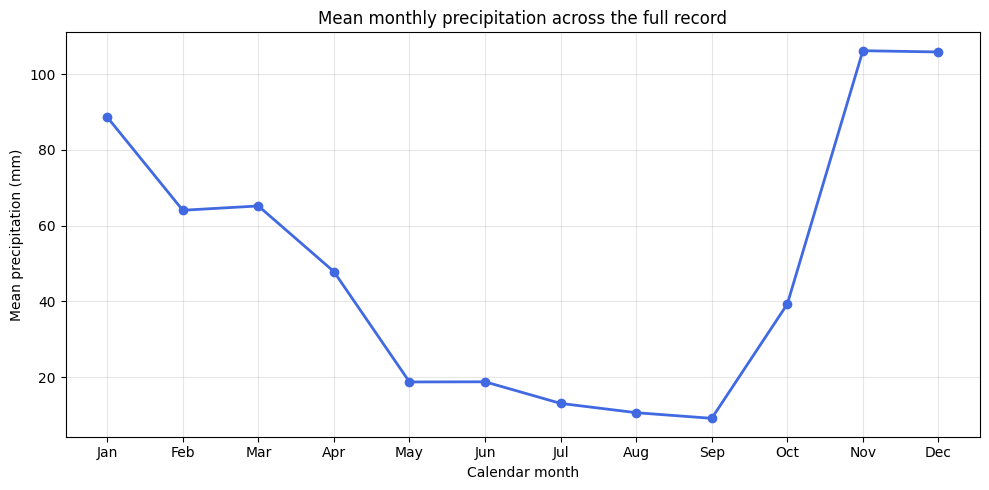

In [30]:
monthly_precip_climatology = (
    rainfall_months.groupby("month")
    .agg(
        mean_precip_mm=("mean_precip_mm", "mean"),
        median_precip_mm=("mean_precip_mm", "median"),
        min_precip_mm=("mean_precip_mm", "min"),
        max_precip_mm=("mean_precip_mm", "max"),
        observations=("mean_precip_mm", "count"),).reset_index())
monthly_precip_climatology["month_name"] = monthly_precip_climatology["month"].map(
    dict(zip(range(1, 13), month_labels)))
print(monthly_precip_climatology.to_string(index=False))
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(monthly_precip_climatology["month"],
    monthly_precip_climatology["mean_precip_mm"],
    color="royalblue", marker="o", linewidth=2,)
ax.set_xticks(range(1, 13), month_labels)
ax.set_xlabel("Calendar month")
ax.set_ylabel("Mean precipitation (mm)")
ax.set_title("Mean monthly precipitation across the full record")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## 8. Green cover and precipitation relationships

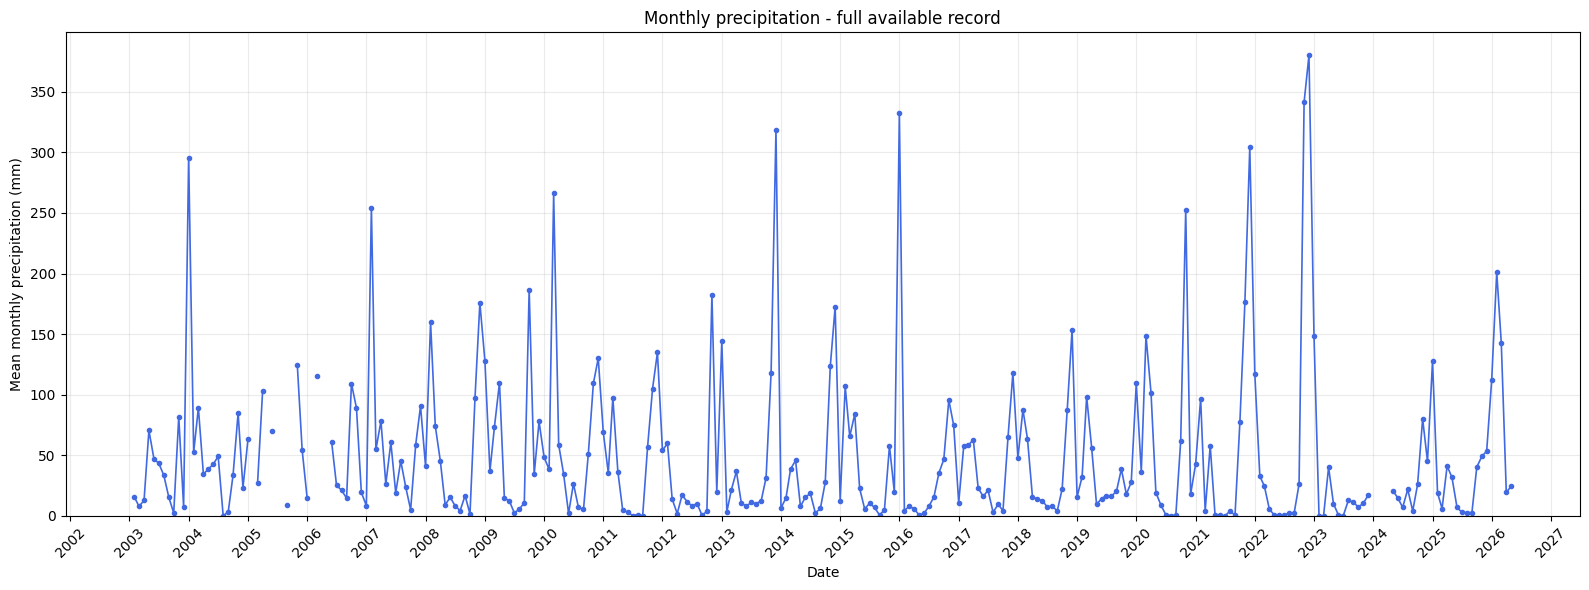

In [31]:
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(precip_analysis["date"], precip_analysis["mean_precip_mm"],
    color="royalblue", marker="o", markersize=3, linewidth=1.2,)
ax.set_xlabel("Date")
ax.set_ylabel("Mean monthly precipitation (mm)")
ax.set_title("Monthly precipitation - full available record")
ax.set_ylim(bottom=0)
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.grid(alpha=0.25)
plt.xticks(rotation=45)
fig.tight_layout()
plt.show()

In [32]:
relationship_all = (
    calendar_df.loc[
        calendar_df["has_both"],
        ["sensor", "date", "green_cover_pct", "mean_precip_mm"],]
    .dropna(subset=["green_cover_pct", "mean_precip_mm"]).copy())

for sensor, group in relationship_all.groupby("sensor"):
    print(f"{sensor}: {group['date'].min():%Y-%m} to "
        f"{group['date'].max():%Y-%m}; {len(group)} matched months")

relationship_all["rainfall_group"] = np.select(
    [relationship_all["mean_precip_mm"] <= dry_limit,relationship_all["mean_precip_mm"] >= wet_limit,],
    ["Dry months", "Wet months"],default="Intermediate months",)

green_wet_dry_summary = (
    relationship_all.loc[
        relationship_all["rainfall_group"].isin(["Dry months", "Wet months"])]
    .groupby(["sensor", "rainfall_group"])
    .agg(
        observations=("green_cover_pct", "count"),
        avg_precip_mm=("mean_precip_mm", "mean"),
        avg_green_cover_pct=("green_cover_pct", "mean"),
        median_green_cover_pct=("green_cover_pct", "median"),
        min_green_cover_pct=("green_cover_pct", "min"),
        max_green_cover_pct=("green_cover_pct", "max"),).reset_index())
print(green_wet_dry_summary.to_string(index=False))

Landsat: 2003-03 to 2026-05; 214 matched months
Sentinel: 2018-12 to 2026-05; 86 matched months
  sensor rainfall_group  observations  avg_precip_mm  avg_green_cover_pct  median_green_cover_pct  min_green_cover_pct  max_green_cover_pct
 Landsat     Dry months            59       3.304520            56.649061               62.150350            11.111111            98.810144
 Landsat     Wet months            48     126.584722            64.726114               70.827975             3.753351           100.000000
Sentinel     Dry months            27       2.401235            66.116422               71.300994            32.896346            87.866023
Sentinel     Wet months            19     166.850000            73.691698               79.967799            40.682234            89.698198
